<a href="https://colab.research.google.com/github/Vimukthi-Nuwan/Deep_Learning/blob/Experiment/CartPole/RL_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📌 Step 1: Install dependencies

In [1]:
!sudo apt-get update
!sudo apt-get install -y xvfb ffmpeg freeglut3-dev
!pip install 'imageio==2.4.0'
!pip install pyglet
!pip install tf-keras
!pip install dm-reverb[tensorflow]
!pip install tensorflow==2.12.0
!pip install pyvirtualdisplay
!pip install reverb
!pip install -y reverb dm-reverb
!pip install tf-agents[reverb]

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,381 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,788 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-upda

  Preparing metadata (setup.py) ... done
  Created wheel for reverb: filename=reverb-2.0.1-py3-none-any.whl size=3673 sha256=9903c24396d74adb268ed7505d3ddb18c31152e750a72c1f91b8ded5b4e6541a
  Stored in directory: /root/.cache/pip/wheels/2b/5f/5e/3e7dc52f583e922e6e98618c7154bc959b04e5024475424c4c
Successfully built reverb

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.4/624.4 kB 10.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tensorflow-2.15.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using ca

### 📌 Step 2: Set environment variable

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

### 📌 Step 3: Import necessary libraries

In [2]:
import reverb
import base64
import random
import imageio
import IPython
import PIL.Image
import matplotlib
import pyvirtualdisplay
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tf_agents.utils import common
from tf_agents.specs import tensor_spec
from tf_agents.drivers import py_driver
from tf_agents.metrics import tf_metrics
from tf_agents.networks import sequential
from tf_agents.agents.dqn import dqn_agent
from tf_agents.environments import suite_gym
from tf_agents.replay_buffers import reverb_utils
from tf_agents.policies import py_tf_eager_policy
from tf_agents.environments import tf_py_environment
from tf_agents.replay_buffers import reverb_replay_buffer
from tf_agents.policies import random_tf_policy, policy_saver

### 📌 Step 4: Set random seed for reproducibility

In [3]:
np.random.seed(0)
tf.random.set_seed(0)
random.seed(0)

### 📌 Step 5: Initialize virtual display
Required for rendering in Colab

In [4]:
display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()

### 📌 Step 6: Define hyperparameters

In [5]:
learning_rate = 1e-3
num_iterations = 2000
initial_collect_steps = 1000
collect_steps_per_iteration = 2
train_steps_per_collect = 5
replay_buffer_max_length = 100000
batch_size = 128
log_interval = 200
eval_interval = 10
num_eval_episodes = 5

### 📌 Step 7: Load the environment

In [6]:
env_name = 'CartPole-v0'
env = suite_gym.load(env_name)
train_py_env = suite_gym.load(env_name)
eval_py_env = suite_gym.load(env_name)
train_env = tf_py_environment.TFPyEnvironment(train_py_env)
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)

### 📌 Step 8: Define the Q-network

In [7]:
action_tensor_spec = env.action_spec()
num_actions = action_tensor_spec.maximum - action_tensor_spec.minimum + 1

dense_layers = [
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
]

q_values_layer = tf.keras.layers.Dense(
    num_actions,
    activation=None,
    kernel_initializer=tf.keras.initializers.VarianceScaling(
        scale=2.0, mode='fan_in', distribution='truncated_normal'),
    bias_initializer=tf.keras.initializers.Constant(-0.2))

q_net = sequential.Sequential(dense_layers + [q_values_layer])

### 📌 Step 9: Initialize the DQN agent

In [8]:
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
train_step_counter = tf.Variable(0)
epsilon = 0.3

agent = dqn_agent.DqnAgent(
    train_env.time_step_spec(),
    train_env.action_spec(),
    q_network=q_net,
    optimizer=optimizer,
    td_errors_loss_fn=common.element_wise_squared_loss,
    train_step_counter=train_step_counter,
    target_update_period=20,
    epsilon_greedy=epsilon)
agent.initialize()

### 📌 Step 10: Define policies

In [9]:
eval_policy = agent.policy
collect_policy = agent.collect_policy
random_policy = random_tf_policy.RandomTFPolicy(train_env.time_step_spec(), train_env.action_spec())

### 📌 Step 11: Function to compute average return

In [10]:
def compute_avg_return(environment, policy, num_episodes=10):
    total_return = 0.0
    for _ in range(num_episodes):
        time_step = environment.reset()
        episode_return = 0.0
        while not time_step.is_last():
            action_step = policy.action(time_step)
            time_step = environment.step(action_step.action)
            reward = np.clip(time_step.reward.numpy(), -1.0, 1.0)
            episode_return += time_step.reward
        total_return += episode_return
    avg_return = total_return / num_episodes
    return avg_return.numpy()[0]

### 📌 Step 12: Set up replay buffer

In [11]:
table_name = 'uniform_table'
replay_buffer_signature = tensor_spec.from_spec(agent.collect_data_spec)
replay_buffer_signature = tensor_spec.add_outer_dim(replay_buffer_signature)

table = reverb.Table(
    table_name,
    max_size=replay_buffer_max_length,
    sampler=reverb.selectors.Uniform(),
    remover=reverb.selectors.Fifo(),
    rate_limiter=reverb.rate_limiters.MinSize(1),
    signature=replay_buffer_signature)

reverb_server = reverb.Server([table])

replay_buffer = reverb_replay_buffer.ReverbReplayBuffer(
    agent.collect_data_spec,
    table_name=table_name,
    sequence_length=2,
    local_server=reverb_server)

rb_observer = reverb_utils.ReverbAddTrajectoryObserver(replay_buffer.py_client, table_name, sequence_length=2)

### 📌 Step 13: Collect initial data

In [12]:
py_driver.PyDriver(env, py_tf_eager_policy.PyTFEagerPolicy(random_policy, use_tf_function=True), [rb_observer], max_steps=initial_collect_steps).run(train_py_env.reset())

dataset = replay_buffer.as_dataset(num_parallel_calls=3, sample_batch_size=batch_size, num_steps=2).prefetch(3)
iterator = iter(dataset)

### 📌 Step 14: Train the agent

In [13]:
agent.train = common.function(agent.train)
agent.train_step_counter.assign(0)
avg_return = compute_avg_return(eval_env, agent.policy, num_eval_episodes)
returns = [avg_return]
time_step = train_py_env.reset()

collect_driver = py_driver.PyDriver(
    env,
    py_tf_eager_policy.PyTFEagerPolicy(agent.collect_policy, use_tf_function=True),
    [rb_observer],
    max_steps=collect_steps_per_iteration
)

for step in range(num_iterations):
    time_step, _ = collect_driver.run(time_step)
    for _ in range(train_steps_per_collect):
        experience, _ = next(iterator)
        train_loss = agent.train(experience)
    if step % 100 == 0 and agent._epsilon_greedy > 0.05:
        agent._epsilon_greedy *= 0.90
    if step % log_interval == 0:
        print(f"step = {step}: loss = {train_loss.loss.numpy()}")
    if step % eval_interval == 0:
        avg_return = compute_avg_return(eval_env, agent.policy, num_eval_episodes)
        print(f"step = {step}: Average Return = {avg_return}")
        returns.append(avg_return)

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.foldr(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.foldr(fn, elems))


step = 0: loss = 0.7879221439361572
step = 0: Average Return = 91.0
step = 10: Average Return = 9.199999809265137
step = 20: Average Return = 9.399999618530273
step = 30: Average Return = 9.0
step = 40: Average Return = 24.600000381469727
step = 50: Average Return = 55.599998474121094
step = 60: Average Return = 78.80000305175781
step = 70: Average Return = 77.5999984741211
step = 80: Average Return = 119.5999984741211
step = 90: Average Return = 153.8000030517578
step = 100: Average Return = 171.1999969482422
step = 110: Average Return = 124.5999984741211
step = 120: Average Return = 181.1999969482422
step = 130: Average Return = 170.8000030517578
step = 140: Average Return = 156.8000030517578
step = 150: Average Return = 170.60000610351562
step = 160: Average Return = 179.39999389648438
step = 170: Average Return = 162.60000610351562
step = 180: Average Return = 134.1999969482422
step = 190: Average Return = 187.0
step = 200: loss = 10.557416915893555
step = 200: Average Return = 117

### 📌 Step 15: Find the first occurrence of 200 for 50 consecutive evaluations

In [14]:
counter = 0
for i in range(len(returns)):
    if returns[i] == 200:
        counter += 1
    else:
        counter = 0
    if counter == 5:  # Check for 50 consecutive occurrences of 200
        print(f"First occurrence of 200 for 50 consecutive evaluations: {(i-4) * eval_interval}")
        break

First occurrence of 200 for 50 consecutive evaluations: 550


### 📌 Step 16: Visualize training performance

🔹 Step 16.1: Plot raw average returns

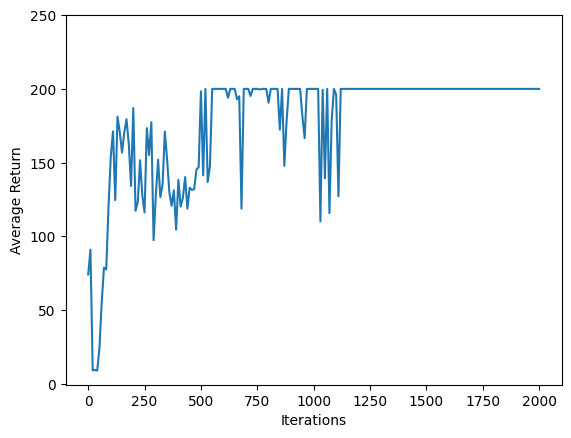

In [15]:
iterations = range(0, num_iterations + 1, eval_interval)
plt.plot(iterations, returns)
plt.ylabel('Average Return')
plt.xlabel('Iterations')
plt.ylim(top=250)
plt.show()

🔹 Step 16.2: Plot smoothed average returns

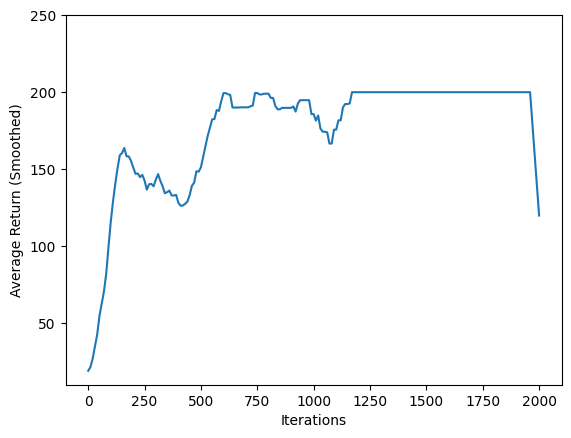

In [16]:
def smooth(data, window_size=10):
    box = np.ones(window_size) / window_size
    return np.convolve(data, box, mode='same')

iterations = range(0, eval_interval * len(returns), eval_interval)
plt.plot(iterations, smooth(returns))
plt.ylabel('Average Return (Smoothed)')
plt.xlabel('Iterations')
plt.ylim(top=250)
plt.show()


### 📌 Step 17: Generate training evaluation videos

In [17]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)

def create_policy_eval_video(policy, filename, num_episodes=25, fps=30):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(num_episodes):
            time_step = eval_env.reset()
            episode_steps = 20
            video.append_data(eval_py_env.render())
            while not time_step.is_last():

                action_step = policy.action(time_step)
                time_step = eval_env.step(action_step.action)
                video.append_data(eval_py_env.render())
    return embed_mp4(filename)


create_policy_eval_video(agent.policy, "trained-agent")


In [18]:
create_policy_eval_video(random_policy, "random-agent")